<img src='sharif_logo.png' alt="SUT logo" width=150 height=150 align=left class="saturate" >

<br>
<font face="Times New Roman">
<div dir=ltr align=center>
<font color=0F5298 size=7>
 Deep Learning <br>
<font color=2565AE size=5>
Computer Engineering Department - Spring 2025  <br>
<font color=3C99D size=5>
          Homework 3: Practical - Oil Price Forecasting
 <br>
<font color=696880 size=4>
            Designer: Mohammad Amanlou
    
    

# 🛢️ Oil Price Prediction using Time Series Models 📈

This notebook is designed for students to complete tasks related to oil price prediction using different machine learning models. 🚀

## 📚 References
- 📊 [Dataset: Yahoo Finance - CL=F](https://finance.yahoo.com/quote/CL=F/history/)
- 📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

## 1️⃣ Introduction
🔍 One of the most common applications of recurrent neural networks is **time series forecasting**. In this assignment, you will predict **crude oil prices** using four different methods. 💡

## 2️⃣ Dataset and Preprocessing (25 Points)

### 📥 2.1 Download Dataset
📌 Download the dataset from **Yahoo Finance** for `CL=F` from **2010 to the present**.
[Yahoo Finance - CL=F](https://finance.yahoo.com/quote/CL=F/history/)

### 🎯 2.2 Select Features
✅ Select the `Adj Close` column as the **main feature**.

### ⚠️ **2.3 Handle Missing Data**

You will encounter missing data (`null` values) within your dataset. Follow these detailed steps carefully to handle the missing values and create a complete, reliable dataset:

#### 📝 Step 1: Introduce Random Missing Data
- Identify all indices in the `Adj Close` column that currently have valid (non-null) data.
- Set a random seed (`np.random.seed(42)`) for reproducibility.
- Randomly select **10%** of these valid indices and set their values to `NaN`.

#### 🔍 Step 2: Identify Missing Values
- Identify all dates where at least one column has a missing value (`NaN`).
- Print the number of missing dates and the total number of dates to evaluate the extent of missingness.

#### 🔧 Step 3: Replace Missing Values
- Create a copy of the `Adj Close` column for filling purposes.
- First, apply **linear interpolation** to estimate missing values based on surrounding data points.
- Then, use backward fill (`bfill`) followed by forward fill (`ffill`) methods to handle any remaining missing values at the start or end of the dataset.

#### 🎯 Outcome:
After completing these steps, your dataset will have no missing values in the `Adj Close` column, ready for further analysis or modeling.

🛠 *Your task:* Implement the missing data handling methods below. (16 Points)

In [2]:
import yfinance as yf
import pandas as pd
from datetime import datetime

end_date = datetime.today().strftime("%Y-%m-%d")

try:
    dataframe = yf.download("CL=F", start="2010-01-01", end=end_date, interval="1d", auto_adjust=False)

    if dataframe.empty:
        raise ValueError("empty")

    dataframe.to_csv("oil_prices.csv")

    feature = dataframe[["Adj Close"]].copy()
    feature.reset_index(drop=True, inplace=True)

    feature.to_csv("oil_prices_adj_close.csv", index=False)

    print(feature.head())

except Exception as e:
    print(f"Error {e}")


[*********************100%***********************]  1 of 1 completed

Price   Adj Close
Ticker       CL=F
0       81.510002
1       81.769997
2       83.180000
3       82.660004
4       82.750000


In [3]:
# TO DO: Introduce random null
import numpy as np
import pandas as pd


if isinstance(feature.columns, pd.MultiIndex):
    feature.columns = feature.columns.get_level_values(0)
    feature.columns.name = None

initial_nan_count = feature['Adj Close'].isna().sum()
print("Initial number of NULL values in 'Adj Close':", initial_nan_count)

valid_indices = feature[feature['Adj Close'].notna()].index

np.random.seed(42)
sample_size = int(0.1 * len(valid_indices))
random_missing_indices = np.random.choice(valid_indices, size=sample_size, replace=False)

feature.loc[random_missing_indices, 'Adj Close'] = np.nan

final_nan_count = feature['Adj Close'].isna().sum()
print("Number of NULL values in 'Adj Close' after random removal:", final_nan_count)


Initial number of NULL values in 'Adj Close': 0
Number of NULL values in 'Adj Close' after random removal: 386


In [4]:
# TO DO: Identify missing dates and null values
total_rows = len(feature)

missing_values = feature['Adj Close'].isna().sum()

rows_with_missing = feature[feature.isna().any(axis=1)].shape[0]

percent_missing = 100 * rows_with_missing / total_rows

print("Total number of rows:", total_rows)
print("Total number of missing values in 'Adj Close':", missing_values)
print("Number of rows (dates) with at least one missing value:", rows_with_missing)
print(f"Percentage of missing rows: {percent_missing:.2f}%")

Total number of rows: 3866
Total number of missing values in 'Adj Close': 386
Number of rows (dates) with at least one missing value: 386
Percentage of missing rows: 9.98%


In [5]:
# TO DO: Fill missing values using .interpolate or .fillna(method='bfill').fillna(method='ffill')

feature_filled = feature.copy()
feature_filled['Adj Close'] = feature_filled['Adj Close'].interpolate(method='linear')
feature_filled['Adj Close'] = feature_filled['Adj Close'].fillna(method='bfill')
feature_filled['Adj Close'] = feature_filled['Adj Close'].fillna(method='ffill')
feature_filled.head()


<ipython-input-5-ad456e73f2c5>:10: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feature_filled['Adj Close'] = feature_filled['Adj Close'].fillna(method='bfill')
<ipython-input-5-ad456e73f2c5>:13: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  feature_filled['Adj Close'] = feature_filled['Adj Close'].fillna(method='ffill')


,Adj Close
0,81.510002
1,81.769997
2,83.180000
3,82.660004
4,82.750000


### ✂️ 2.4 Train-Test Split and Normalization
- **Split** the dataset into **training and test sets** based on the ratio given in the reference paper.
- **Normalize** the data.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

🛠 *Your task:* Implement the splitting and normalization below. (4 Points)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
def temporal_split(series, train_ratio=0.6, val_ratio=0.2):
    n = len(series)
    train_end = int(n * train_ratio)
    val_end = train_end + int(n * val_ratio)
    train = series.iloc[:train_end]
    val = series.iloc[train_end:val_end]
    test = series.iloc[val_end:]
    return train, val, test

train_list, val_list, test_list = [], [], []

train, val, test = temporal_split(feature_filled)
train_list.append(train)
val_list.append(val)
test_list.append(test)

train_data = pd.concat(train_list)
val_data = pd.concat(val_list)
test_data = pd.concat(test_list)

scaler = MinMaxScaler()
train_data['Adj Close'] = scaler.fit_transform(train_data[['Adj Close']])
val_data['Adj Close'] = scaler.transform(val_data[['Adj Close']])
test_data['Adj Close'] = scaler.transform(test_data[['Adj Close']])

print("Training data sample:")
print(train_data.head())
print("Testing data sample:")
print(test_data.head())


Training data sample:
   Adj Close
0   0.630415
1   0.633379
2   0.649453
3   0.643525
4   0.644551
Testing data sample:
      Adj Close
3092   0.870383
3093   0.872549
3094   0.868673
3095   0.864797
3096   0.824555


### 📊 2.5 Data Visualization
- **Plot a histogram** similar to **Figure 6** in the reference paper, showing the **distribution of oil prices**.

🛠 *Your task:* Implement the histogram plot below. (5 Points)

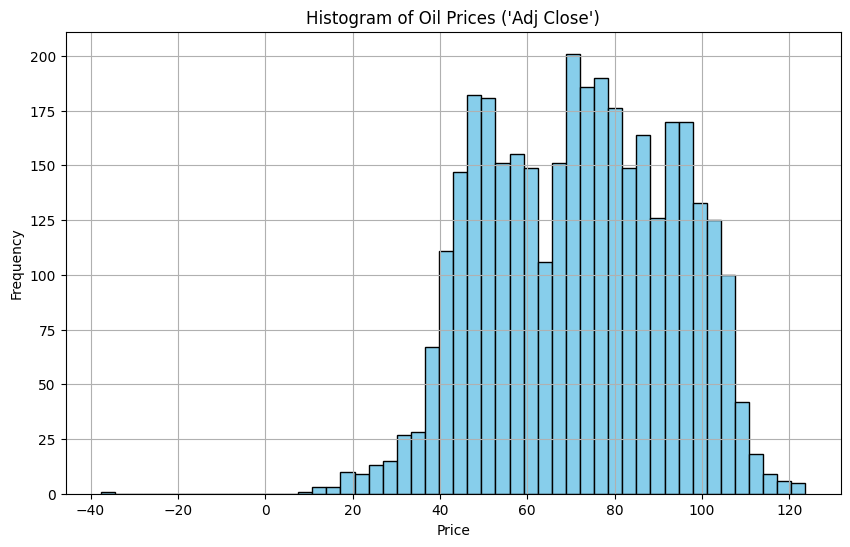

In [9]:
# TO DO: Plot histogram of 'Adj Close'
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(feature['Adj Close'], bins=50, color='skyblue', edgecolor='black')
plt.title("Histogram of Oil Prices ('Adj Close')")
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()


## 3️⃣ Implementing Deep Learning Models 🤖 (60 Points)

The reference paper utilizes **three models** for time series forecasting:
- `RNN`
- `LSTM`
- `GRU`

📌 **Train** each model using the **hyperparameters** given in **Table 4** of the paper.
📌 Use `Mean Square Error (MSE)` as the **loss function**.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)


### Important Details & Clarifications

- **What to Predict?**  
  The goal is to predict **the actual next-day price** (regression problem), rather than just identifying price increase or decrease.
  
- **Input/Output Structure:**  
  - **Input:** A window of \( k \) consecutive daily prices (e.g., 50 days).  
  - **Output:** The predicted price for the next day.
  
- **How to Evaluate?**  
  Use the four metrics (RMSE, MAE, MAPE, \( R^2 \)) to gauge how accurately your model tracks the real price values.

- **Target Accuracy:**  
  Your accuracy might differ from the paper’s due to factors like data splitting, normalization, or different random seeds. However, aim to closely replicate the paper’s results or provide justifications for any discrepancy.

**Final Deliverables:**
1. **All four trained models** (RNN, LSTM, GRU).  
2. **Comparison plots** of predicted vs. actual values (in both normalized and original price scales, if desired).  
3. **Performance metrics** (RMSE, MAE, MAPE, \( R^2 \)) for each model, presented in a table or a concise summary.


🛠 *Your task:* Implement these models below. (30 Points)

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

def create_sequences(data, window_size):
    sequences = []
    targets = []
    for i in range(len(data) - window_size):
        seq = data[i:i+window_size]
        target = data[i+window_size]
        sequences.append(seq)
        targets.append(target)
    return torch.tensor(sequences, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

window_size = 50

train_values = train_data['Adj Close'].values
test_values = test_data['Adj Close'].values

X_train, y_train = create_sequences(train_values, window_size)
X_test, y_test = create_sequences(test_values, window_size)

batch_size = 64

train_dataset = TensorDataset(X_train.unsqueeze(-1), y_train.unsqueeze(-1))
test_dataset = TensorDataset(X_test.unsqueeze(-1), y_test.unsqueeze(-1))

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)



<ipython-input-10-5fa46c504d3c>:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:254.)
  return torch.tensor(sequences, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)


In [11]:
import torch
import torch.nn as nn

class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=2, output_size=1):
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # x shape: (batch_size, seq_len, input_size)
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)

        out, _ = self.lstm(x, (h0, c0))
        out = out[:, -1, :]
        out = self.fc(out)
        return out


lstm_model = LSTMModel()
optimizer = torch.optim.Adam(lstm_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()

def train_model(model, train_loader, test_loader, epochs=50, device='cpu'):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = loss_fn(outputs, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * X_batch.size(0)

        train_loss /= len(train_loader.dataset)

        model.eval()
        test_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = loss_fn(outputs, y_batch)
                test_loss += loss.item() * X_batch.size(0)
        test_loss /= len(test_loader.dataset)

        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.6f} | Test Loss: {test_loss:.6f}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_model(lstm_model, train_loader, test_loader, epochs=50, device=device)


Epoch 1/50 | Train Loss: 0.150321 | Test Loss: 0.004212
Epoch 2/50 | Train Loss: 0.013386 | Test Loss: 0.005042
Epoch 3/50 | Train Loss: 0.002262 | Test Loss: 0.002197
Epoch 4/50 | Train Loss: 0.001609 | Test Loss: 0.001624
Epoch 5/50 | Train Loss: 0.001281 | Test Loss: 0.001444
Epoch 6/50 | Train Loss: 0.001195 | Test Loss: 0.001381
Epoch 7/50 | Train Loss: 0.001138 | Test Loss: 0.001342
Epoch 8/50 | Train Loss: 0.001076 | Test Loss: 0.001283
Epoch 9/50 | Train Loss: 0.001038 | Test Loss: 0.001316
Epoch 10/50 | Train Loss: 0.000985 | Test Loss: 0.001210
Epoch 11/50 | Train Loss: 0.000978 | Test Loss: 0.001358
Epoch 12/50 | Train Loss: 0.000902 | Test Loss: 0.001190
Epoch 13/50 | Train Loss: 0.000874 | Test Loss: 0.001110
Epoch 14/50 | Train Loss: 0.000830 | Test Loss: 0.001318
Epoch 15/50 | Train Loss: 0.000900 | Test Loss: 0.001247
Epoch 16/50 | Train Loss: 0.000854 | Test Loss: 0.001102
Epoch 17/50 | Train Loss: 0.000776 | Test Loss: 0.001031
Epoch 18/50 | Train Loss: 0.000720 | Tes

In [12]:


class RNNModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_layers=1, output_size=1):
        super(RNNModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        out, _ = self.rnn(x, h0)
        out = self.fc(out[:, -1, :])
        return out

rnn_model = RNNModel()
optimizer = torch.optim.Adam(rnn_model.parameters(), lr=0.001)
loss_fn = nn.MSELoss()
train_model(rnn_model, train_loader, test_loader)


Epoch 1/50 | Train Loss: 0.121279 | Test Loss: 0.010173
Epoch 2/50 | Train Loss: 0.014377 | Test Loss: 0.000972
Epoch 3/50 | Train Loss: 0.000991 | Test Loss: 0.001117
Epoch 4/50 | Train Loss: 0.000695 | Test Loss: 0.000891
Epoch 5/50 | Train Loss: 0.000645 | Test Loss: 0.000771
Epoch 6/50 | Train Loss: 0.000614 | Test Loss: 0.000900
Epoch 7/50 | Train Loss: 0.000626 | Test Loss: 0.000855
Epoch 8/50 | Train Loss: 0.000556 | Test Loss: 0.000781
Epoch 9/50 | Train Loss: 0.000557 | Test Loss: 0.000777
Epoch 10/50 | Train Loss: 0.000545 | Test Loss: 0.000736
Epoch 11/50 | Train Loss: 0.000536 | Test Loss: 0.000800
Epoch 12/50 | Train Loss: 0.000517 | Test Loss: 0.000719
Epoch 13/50 | Train Loss: 0.000505 | Test Loss: 0.000954
Epoch 14/50 | Train Loss: 0.000500 | Test Loss: 0.000942
Epoch 15/50 | Train Loss: 0.000492 | Test Loss: 0.000782
Epoch 16/50 | Train Loss: 0.000480 | Test Loss: 0.000725
Epoch 17/50 | Train Loss: 0.000471 | Test Loss: 0.000775
Epoch 18/50 | Train Loss: 0.000449 | Tes

In [13]:
# GRU
import torch.nn as nn
import torch

class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=50, num_stacked_layers=1, batch_first=True):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_stacked_layers = num_stacked_layers

        self.gru = nn.GRU(input_size, hidden_size, num_stacked_layers, batch_first=batch_first)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        batch_size = x.size(0)
        h0 = torch.zeros(self.num_stacked_layers, batch_size, self.hidden_size).to(x.device)

        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out


gru_model = GRUModel()
optimizer = torch.optim.Adam(gru_model.parameters(), lr=0.001)
train_model(gru_model, train_loader, test_loader)

Epoch 1/50 | Train Loss: 0.135677 | Test Loss: 0.006542
Epoch 2/50 | Train Loss: 0.025397 | Test Loss: 0.002797
Epoch 3/50 | Train Loss: 0.012825 | Test Loss: 0.001084
Epoch 4/50 | Train Loss: 0.001589 | Test Loss: 0.001070
Epoch 5/50 | Train Loss: 0.000642 | Test Loss: 0.000848
Epoch 6/50 | Train Loss: 0.000596 | Test Loss: 0.000833
Epoch 7/50 | Train Loss: 0.000562 | Test Loss: 0.000809
Epoch 8/50 | Train Loss: 0.000514 | Test Loss: 0.000792
Epoch 9/50 | Train Loss: 0.000486 | Test Loss: 0.000735
Epoch 10/50 | Train Loss: 0.000472 | Test Loss: 0.000703
Epoch 11/50 | Train Loss: 0.000466 | Test Loss: 0.000688
Epoch 12/50 | Train Loss: 0.000446 | Test Loss: 0.000729
Epoch 13/50 | Train Loss: 0.000447 | Test Loss: 0.000703
Epoch 14/50 | Train Loss: 0.000435 | Test Loss: 0.000730
Epoch 15/50 | Train Loss: 0.000419 | Test Loss: 0.000648
Epoch 16/50 | Train Loss: 0.000407 | Test Loss: 0.000644
Epoch 17/50 | Train Loss: 0.000410 | Test Loss: 0.000629
Epoch 18/50 | Train Loss: 0.000420 | Tes

### 📈 3.1 Prediction and Evaluation
1. **Prediction:** After training, generate predictions for the test set (i.e., predict the next-day price based on the preceding \( k \) days).
2. **Visualization:** **Plot the predicted values** alongside the **actual values** for each model. This comparison helps in visually assessing each model’s performance.

🛠 **Your Task:** Implement the **visualization of predictions** (15 Points).

In [14]:
# Predictions
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def predict(model, data_loader):
    model.to(device)
    model.eval()

    predictions = []
    actuals = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            output = model(X_batch)

            predictions.append(output.cpu())
            actuals.append(y_batch.cpu())

    predictions = torch.cat(predictions).numpy()
    actuals = torch.cat(actuals).numpy()

    return predictions, actuals

pred_lstm, actual_lstm = predict(lstm_model, test_loader)
pred_gru, actual_gru = predict(gru_model, test_loader)
pred_rnn, actual_rnn = predict(rnn_model, test_loader)


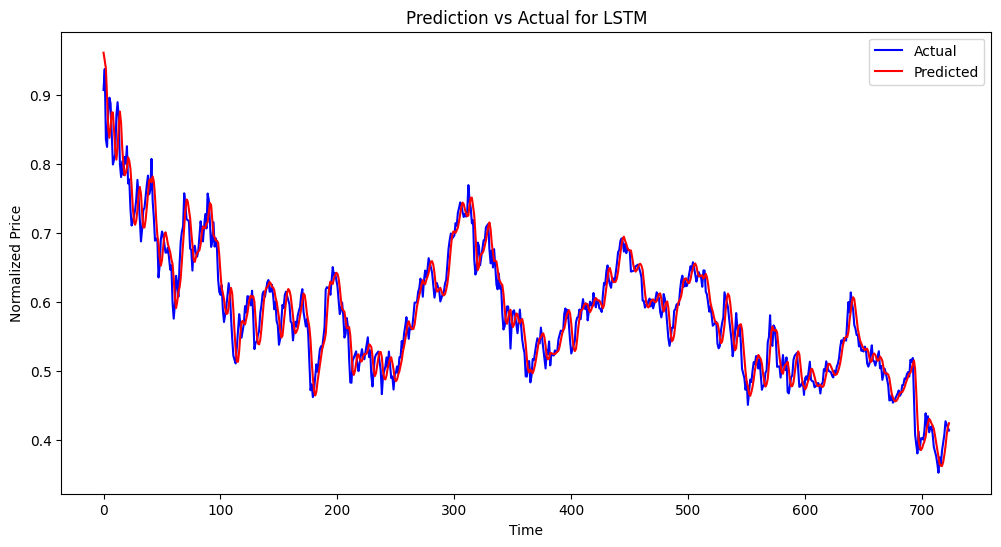

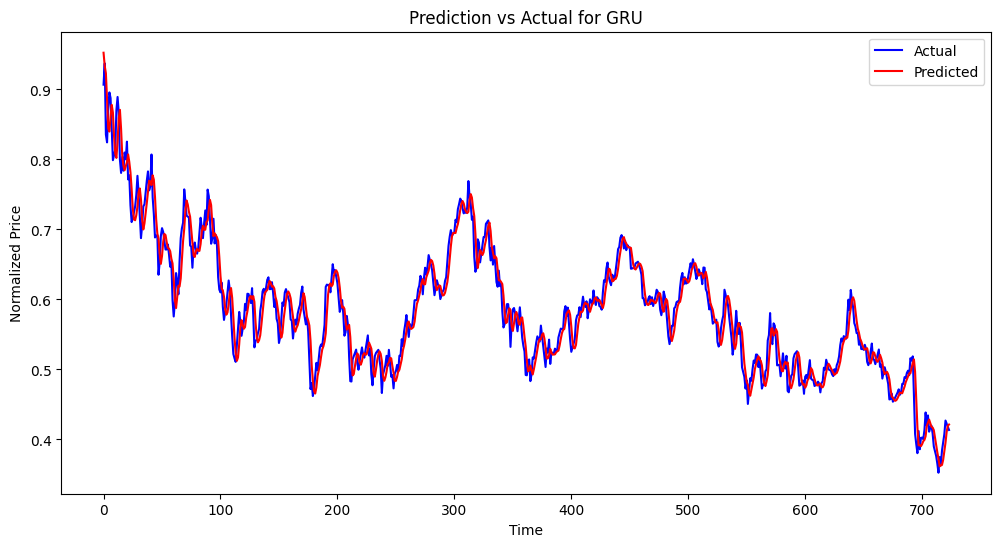

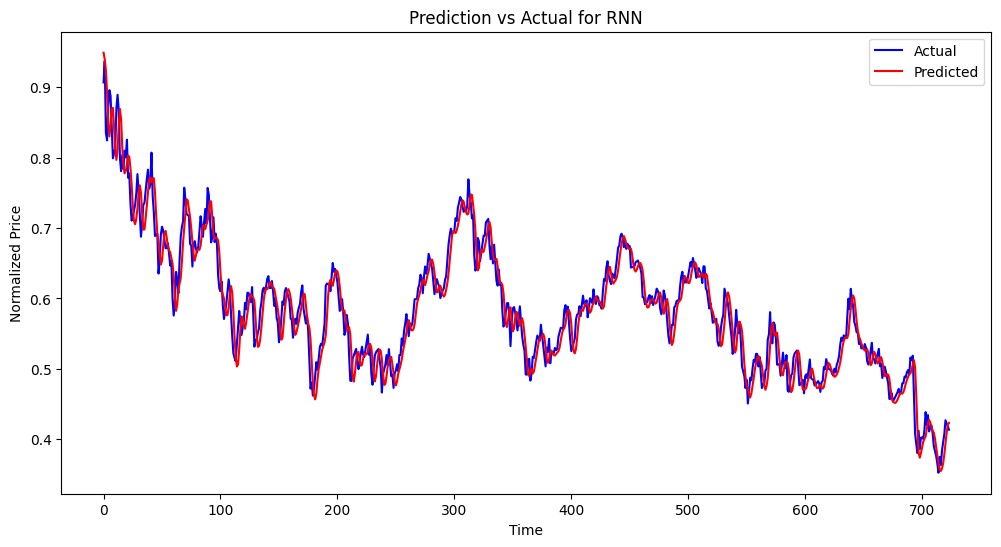

In [15]:
import matplotlib.pyplot as plt

def plot_predictions(predictions, actual, model_name):
    plt.figure(figsize=(12,6))
    plt.plot(actual, label='Actual', color='blue')
    plt.plot(predictions, label='Predicted', color='red')
    plt.title(f'Prediction vs Actual for {model_name}')
    plt.xlabel('Time')
    plt.ylabel('Normalized Price')
    plt.legend()
    plt.show()

plot_predictions(pred_lstm, actual_lstm, 'LSTM')
plot_predictions(pred_gru, actual_gru, 'GRU')
plot_predictions(pred_rnn, actual_rnn, 'RNN')


### 📊 3.2 Error Metrics
📌 Explain the following **error metrics** used in the paper:
- `RMSE` (Root Mean Square Error)
- `MAE` (Mean Absolute Error)
- `MAPE` (Mean Absolute Percentage Error)
- `R-Squared` (Coefficient of Determination)

**📌 Instruction:**  
Explain each of these error metrics and calculate them for **each model** (RNN, LSTM, GRU). Compare your results with the paper’s findings to see how closely they match.

🛠 *Your task:* Implement the evaluation metrics below. (15 Points)

In [16]:
# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def calculate_metrics(predictions, actual):
    rmse = np.sqrt(mean_squared_error(actual, predictions))
    mae = mean_absolute_error(actual, predictions)
    mape = np.mean(np.abs((actual - predictions) / actual)) * 100
    r2 = r2_score(actual, predictions)

    return {
        'RMSE': rmse,
        'MAE': mae,
        'MAPE (%)': mape,
        'R2': r2
    }

actual_values = actual_rnn

print("RNN Metrics (Unscaled):", calculate_metrics(pred_rnn, actual_values))
print("LSTM Metrics (Unscaled):", calculate_metrics(pred_lstm, actual_values))
print("GRU Metrics (Unscaled):", calculate_metrics(pred_gru, actual_values))


RNN Metrics (Unscaled): {'RMSE': 0.02496143184241004, 'MAE': 0.019643979147076607, 'MAPE (%)': 3.3836953341960907, 'R2': 0.9274078011512756}
LSTM Metrics (Unscaled): {'RMSE': 0.024954320854453878, 'MAE': 0.01933129131793976, 'MAPE (%)': 3.343230113387108, 'R2': 0.9274491667747498}
GRU Metrics (Unscaled): {'RMSE': 0.023023601475414223, 'MAE': 0.017911620438098907, 'MAPE (%)': 3.0888568609952927, 'R2': 0.9382414221763611}


In [28]:
data.rename(columns={
    'Unnamed: 1': 'Adj Close',
    'Unnamed: 3': 'High',
    'Unnamed: 4': 'Low',
    'Unnamed: 5': 'Open',
    'Unnamed: 6': 'Volume'
}, inplace=True)

data['Date'] = pd.to_datetime(data['Date'])

# Fill missing values for all features

filled_data = data.copy()
for column in ['Open', 'High', 'Low', 'Volume', 'Adj Close']:
    filled_data[column] = filled_data[column].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')

# Split data
train_data = filled_data.iloc[:-int(0.3 * len(filled_data))]
test_data = filled_data.iloc[-int(0.3 * len(filled_data)):]
train_target = train_data['Adj Close']
train_exog = train_data[['Open', 'High', 'Low', 'Volume']]
test_exog = test_data[['Open', 'High', 'Low', 'Volume']]

# ADF Test
from statsmodels.tsa.stattools import adfuller
result = adfuller(train_data['Adj Close'])
print(f"ADF Statistic: {result[0]}")
print(f"p-value: {result[1]}")
print(f"Critical Values: {result[4]}")
print("The series is stationary." if result[1] < 0.05 else "The series is not stationary.")


<ipython-input-28-547d4fc748d8>:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  filled_data[column] = filled_data[column].interpolate(method='linear').fillna(method='bfill').fillna(method='ffill')


ADF Statistic: -1.3116909293860506
p-value: 0.6238068712106325
Critical Values: {'1%': -3.432771576399878, '5%': -2.862609874912307, '10%': -2.567339529861519}
The series is not stationary.


In [29]:
import pandas as pd

data = pd.read_csv('/content/oil_prices.csv')
print(data.columns)
print(data.head())


Index(['Price', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')
        Price          Adj Close              Close               High  \
0      Ticker               CL=F               CL=F               CL=F   
1        Date                NaN                NaN                NaN   
2  2010-01-04  81.51000213623047  81.51000213623047  81.68000030517578   
3  2010-01-05   81.7699966430664   81.7699966430664               82.0   
4  2010-01-06  83.18000030517578  83.18000030517578   83.5199966430664   

                 Low               Open  Volume  
0               CL=F               CL=F    CL=F  
1                NaN                NaN     NaN  
2  79.62999725341797  79.62999725341797  263542  
3  80.94999694824219  81.62999725341797  258887  
4   80.8499984741211  81.43000030517578  370059  


## 4️⃣ ARIMA Model 📉 (15 Points)

📌 Explain the **difference** between `ARIMA` and `SARIMA` models.

📌 List the **advantages** and **limitations** of `ARIMA`.

📌 Explain the **mathematical formulation** of `ARIMA`, including its **parameters**.

📌 Determine the **optimal parameters** for `ARIMA` and **report the results**.

📌 Compare the results with **Table 6** from the paper.

📄 [Reference Paper](https://www.ijournalse.org/index.php/ESJ/article/view/21497)

🛠 *Your task:* Implement the ARIMA model below.

In [30]:
!pip install numpy==1.24.4 --force-reinstall

  Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
Using cached numpy-1.24.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (17.3 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.24.4
    Uninstalling numpy-1.24.4:
      Successfully uninstalled numpy-1.24.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
jax 0.5.2 requires numpy>=1.25, but you have numpy 1.24.4 which is incompatible.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.24.4 which is incompatible.
treescope 0.1.9 requires numpy>=1.25.2, but you have numpy 1.24.4 which is incompatible.
pymc 5.22.0 requires numpy>=1.25.0, but you have numpy 1.24.4 which is incompatible.
blosc2 3.3.2 requires numpy>=1.26, but you have numpy 1.24.4 which is incompatible.
jaxlib 0.5.1 requires numpy>=1.25, but you h

In [31]:
# Train ARIMA model using auto_arima
!pip install pmdarima
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA

#TO DO:Find optimal arima model using auto_arima
arima_model = auto_arima(train_data['Adj Close'],
                         exogenous=train_exog,
                         seasonal=False,
                         trace=True,
                         error_action='ignore',
                         suppress_warnings=True,
                         stepwise=True)
print(f"Optimal ARIMA Order: {arima_model.order}")

final_model = ARIMA(train_data['Adj Close'],
                    order=arima_model.order,
                    exog=train_exog).fit()

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

preds = final_model.predict(start=test_data.index[0],
                            end=test_data.index[-1],
                            exog=test_exog)

true = test_data['Adj Close']

rmse = np.sqrt(mean_squared_error(true, preds))
mae = mean_absolute_error(true, preds)
r2 = r2_score(true, preds)

print(f"ARIMA RMSE: {rmse}")
print(f"ARIMA MAE: {mae}")
print(f"ARIMA R2: {r2}")


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=11160.004, Time=8.15 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=11341.084, Time=0.11 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=11174.814, Time=0.34 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,1,2)(0,0,0)[0]             : AIC=11156.909, Time=0.48 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=11173.082, Time=0.13 sec


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,1,2)(0,0,0)[0]             : AIC=11158.778, Time=2.61 sec

Best model:  ARIMA(0,1,1)(0,0,0)[0]          
Total fit time: 24.842 seconds
Optimal ARIMA Order: (0, 1, 1)


/usr/local/lib/python3.11/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA RMSE: 8.04176386020976
ARIMA MAE: 7.412571572123774
ARIMA R2: 0.6964056885224339


Predicted values:
2707    39.933303
2708    40.853213
2709    40.519186
2710    39.315700
2711    40.325523
          ...    
3861    58.406718
3862    58.687741
3863    58.334760
3864    56.310846
3865    57.795120
Name: predicted_mean, Length: 1159, dtype: float64


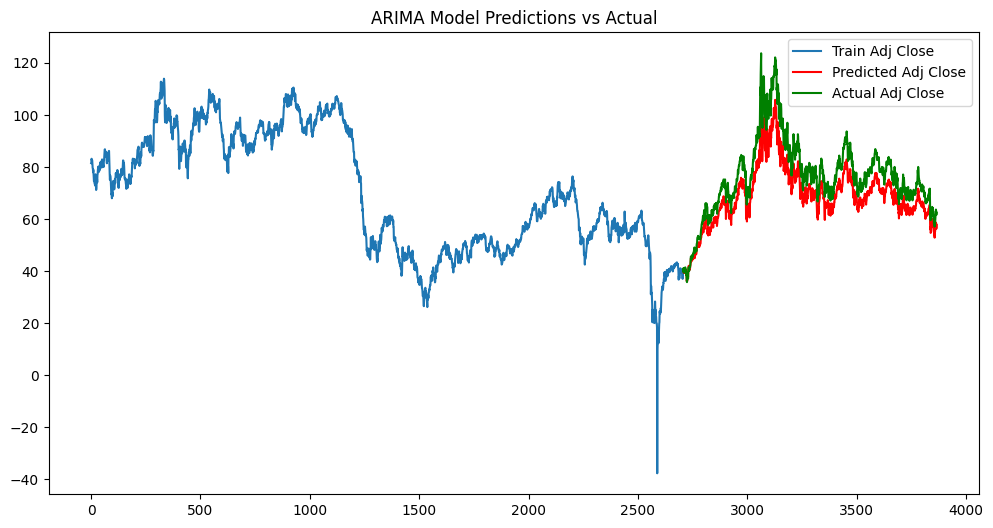

In [32]:
import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from tqdm import tqdm
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore", category=UserWarning, module="statsmodels")
warnings.filterwarnings("ignore", category=ConvergenceWarning, module="statsmodels")

# TO DO: Predict Arima outputs

p, d, q = 2, 1, 2

model = ARIMA(endog=train_target, exog=train_exog, order=(p, d, q))
model_fit = model.fit()

pred = model_fit.predict(start=len(train_target), end=len(train_target)+len(test_exog)-1, exog=test_exog)

print("Predicted values:")
print(pred)

import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train_target.index, train_target, label='Train Adj Close')
plt.plot(test_exog.index, pred, label='Predicted Adj Close', color='red')
plt.plot(test_exog.index, test_data['Adj Close'], label='Actual Adj Close', color='green')
plt.legend()
plt.title("ARIMA Model Predictions vs Actual")
plt.show()


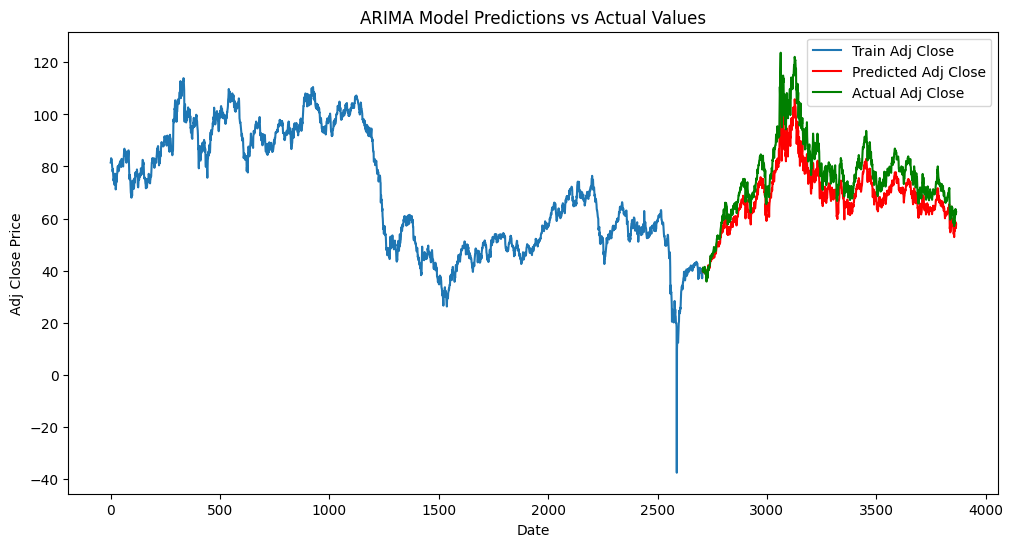

In [33]:
#TO DO: Plot ARIMA vs actual
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(train_target.index, train_target, label='Train Adj Close')
plt.plot(test_exog.index, pred, label='Predicted Adj Close', color='red')
plt.plot(test_exog.index, test_data['Adj Close'], label='Actual Adj Close', color='green')
plt.xlabel('Date')
plt.ylabel('Adj Close Price')
plt.title('ARIMA Model Predictions vs Actual Values')
plt.legend()
plt.show()



In [34]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

order_combinations = [(3,1,2)]
seasonal_combinations = [(3,1,1,12)]

# Initialize variables to store the best results
best_aic = float("inf")
best_order = None
best_seasonal_order = None
best_model = None

# Grid search over all parameter combinations
for order in order_combinations:
    for seasonal_order in seasonal_combinations:
        try:
            # Train SARIMA model
            model = SARIMAX(train_target, exog=train_exog, order=order, seasonal_order=seasonal_order)
            model_fit = model.fit(disp=False)

            # Check AIC
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = order
                best_seasonal_order = seasonal_order
                best_model = model_fit

        except Exception as e:
            print(e)
            continue

print(f"Best SARIMA Model: Order={best_order}, Seasonal_Order={best_seasonal_order}, AIC={best_aic}")
print(best_model.summary())


Best SARIMA Model: Order=(3, 1, 2), Seasonal_Order=(3, 1, 1, 12), AIC=5605.1628403951745
                                      SARIMAX Results                                       
Dep. Variable:                            Adj Close   No. Observations:                 2707
Model:             SARIMAX(3, 1, 2)x(3, 1, [1], 12)   Log Likelihood               -2788.581
Date:                              Mon, 19 May 2025   AIC                           5605.163
Time:                                      19:44:57   BIC                           5687.746
Sample:                                           0   HQIC                          5635.031
                                             - 2707                                         
Covariance Type:                                opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Open     

In [35]:
#TO DO: Batch forecasting for SARIMA
#TO DO: Batch forecasting for SARIMA

n_test = len(test_exog)

forecast = best_model.get_forecast(steps=n_test, exog=test_exog)

forecast_mean = forecast.predicted_mean
forecast_conf_int = forecast.conf_int()

print(forecast_mean.head())



2707    40.328394
2708    41.198628
2709    40.488306
2710    39.547070
2711    40.149835
Name: predicted_mean, dtype: float64


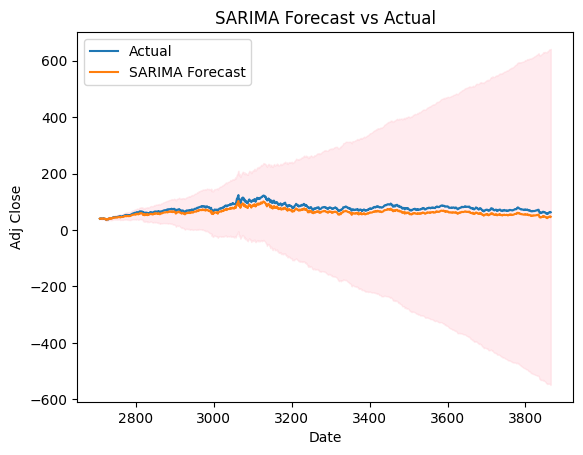

In [36]:
#TO DO: Plot SARIMA vs actual
import matplotlib.pyplot as plt

plt.plot(test_data.index, test_data['Adj Close'], label='Actual')

plt.plot(test_data.index, forecast_mean, label='SARIMA Forecast')

plt.fill_between(test_data.index,
                 forecast_conf_int.iloc[:, 0],
                 forecast_conf_int.iloc[:, 1],
                 color='pink', alpha=0.3)

plt.title('SARIMA Forecast vs Actual')
plt.xlabel('Date')
plt.ylabel('Adj Close')
plt.legend()
plt.show()

